In [ ]:
# Section 1: Setup

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from copy import deepcopy
from tqdm import tqdm

# reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

In [109]:
# PDE Sample Generator

def generate_sample(K, N=64, r=0.5):

    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)

    X, Y = np.meshgrid(x,y)

    coeffs = np.random.randn(K,K)

    u = np.zeros_like(X)
    f = np.zeros_like(X)

    for i in range(1,K+1):
        for j in range(1,K+1):

            phi = (
                np.sin(np.pi*i*X)
                * np.sin(np.pi*j*Y)
            )

            coeff_u = (
                coeffs[i-1,j-1]
                * (i**2+j**2)**(r-1)
                / (np.pi*K**2)
            )

            coeff_f = (
                np.pi*K**2
                * coeffs[i-1,j-1]
                * (i**2+j**2)**r
            )

            u += coeff_u * phi
            f += coeff_f * phi

    return X, Y, f, u, coeffs

In [110]:
X, Y, f, u, _ = generate_sample(K)

print("Grid shape:", X.shape)
print("Source shape:", f.shape)
print("Solution shape:", u.shape)

Grid shape: (64, 64)
Source shape: (64, 64)
Solution shape: (64, 64)


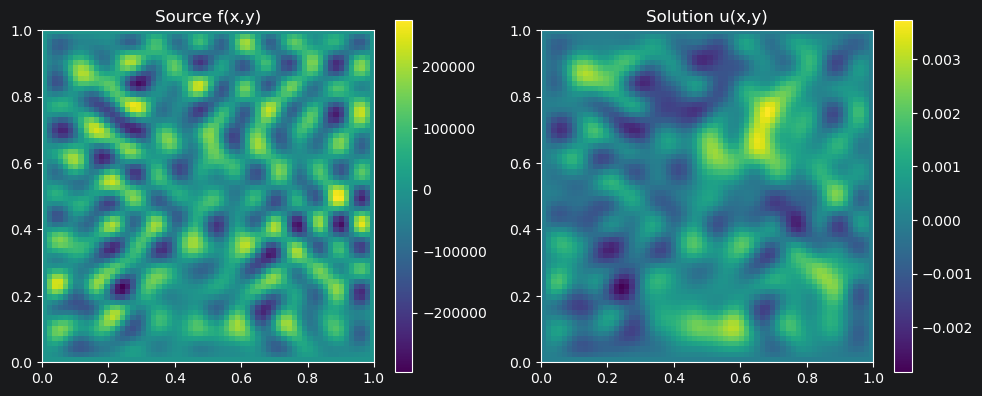

In [111]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(10,4)
)

im0 = ax[0].imshow(
    f,
    origin="lower",
    extent=[0,1,0,1]
)
ax[0].set_title("Source f(x,y)")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(
    u,
    origin="lower",
    extent=[0,1,0,1]
)
ax[1].set_title("Solution u(x,y)")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

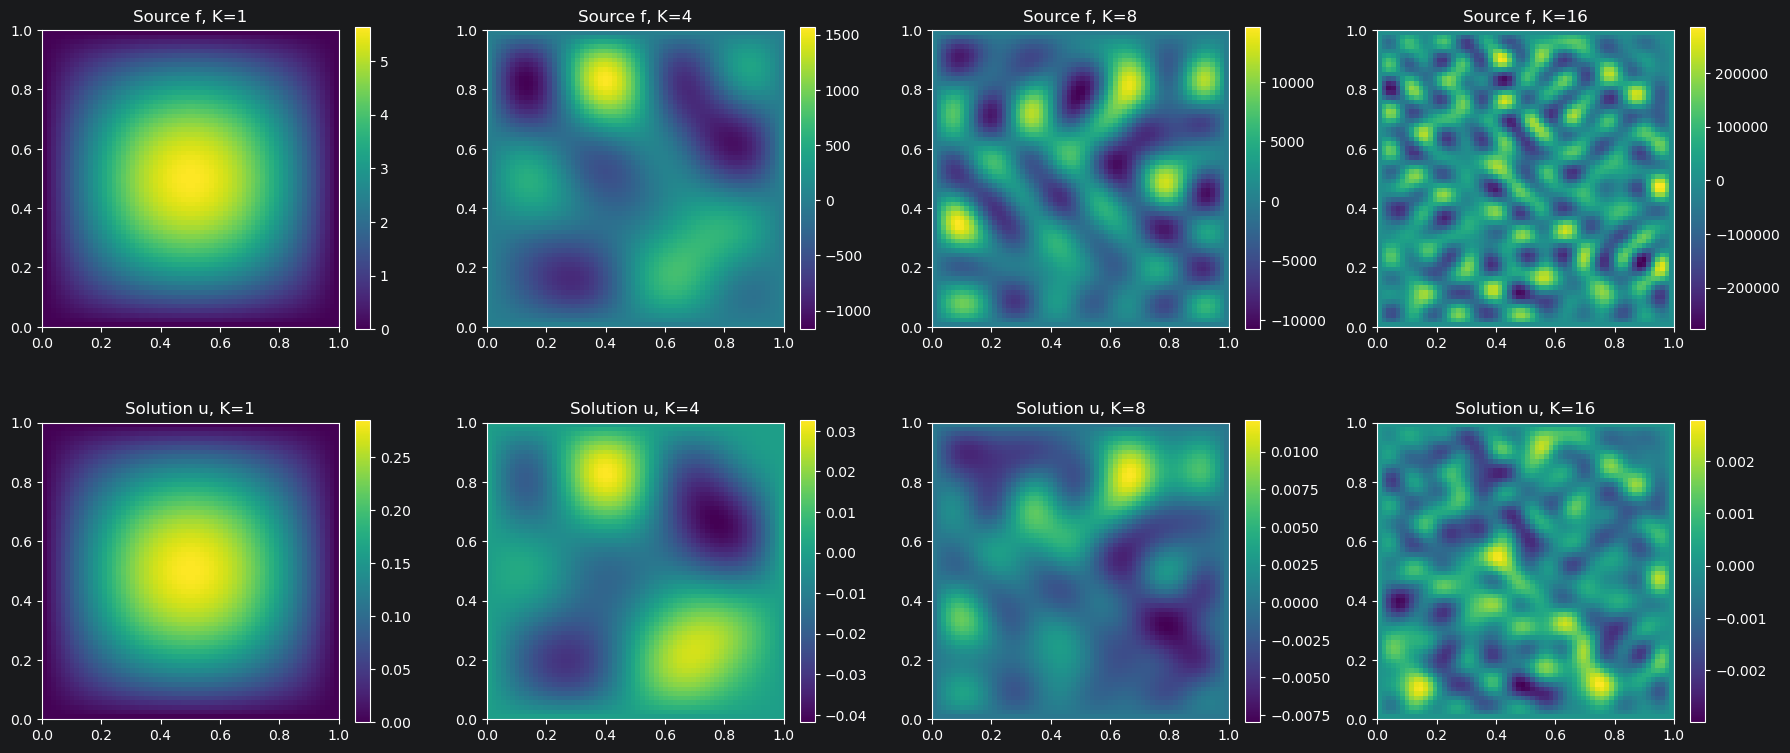

In [112]:
Ks = [1, 4, 8, 16]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

for col, K in enumerate(Ks):

    X, Y, f, u, _ = generate_sample(K)

    im1 = axes[0, col].imshow(
        f,
        origin="lower",
        extent=[0,1,0,1]
    )

    axes[0, col].set_title(
        f"Source f, K={K}"
    )

    plt.colorbar(
        im1,
        ax=axes[0,col],
        fraction=0.046
    )

    im2 = axes[1, col].imshow(
        u,
        origin="lower",
        extent=[0,1,0,1]
    )

    axes[1, col].set_title(
        f"Solution u, K={K}"
    )

    plt.colorbar(
        im2,
        ax=axes[1,col],
        fraction=0.046
    )

plt.tight_layout()
plt.show()

In [113]:
benchmark_cases = {}

for K in [1,4,16]:

    X, Y, f, u, coeffs = generate_sample(K)

    benchmark_cases[K] = {
        "X": X,
        "Y": Y,
        "f": f,
        "u": u,
        "coeffs": coeffs
    }

print("Saved benchmark cases:")
print(list(benchmark_cases.keys()))

Saved benchmark cases:
[1, 4, 16]


In [114]:
# Shared MLP Architecture

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2, 512),
            nn.Tanh(),

            nn.Linear(512, 512),
            nn.Tanh(),

            nn.Linear(512, 512),
            nn.Tanh(),

            nn.Linear(512, 512),
            nn.Tanh(),

            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.net(x)

In [115]:
# Create supervised dataset

def create_supervised_dataset(case):

    X = case["X"]
    Y = case["Y"]
    U = case["u"]

    coords = np.stack(
    [
        2*X.flatten()-1,
        2*Y.flatten()-1
    ],
    axis=1
  )
    targets = U.flatten()[:, None]

    coords = torch.tensor(
        coords,
        dtype=torch.float32
    )

    targets = torch.tensor(
        targets,
        dtype=torch.float32
    )

    return coords, targets

In [116]:
# Relative L2 Error

def relative_l2_error(pred, true):

    return (
        torch.norm(pred - true)
        /
        torch.norm(true)
    ).item()

In [117]:
# Data Driven Training

def train_data_driven(
    model,
    coords,
    targets,
    adam_epochs=5000,
    lr=1e-3
):

    coords = coords.to(device)
    targets = targets.to(device)

    loss_history = []

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    print("Adam training...")

    for epoch in tqdm(range(adam_epochs)):

        optimizer.zero_grad()

        pred = model(coords)

        loss = F.mse_loss(
            pred,
            targets
        )

        loss.backward()

        optimizer.step()

        loss_history.append(
            loss.item()
        )

    print("Switching to LBFGS...")

    optimizer_lbfgs = optim.LBFGS(
        model.parameters(),
        max_iter=500,
        tolerance_grad=1e-9,
        tolerance_change=1e-9
    )

    def closure():

        optimizer_lbfgs.zero_grad()

        pred = model(coords)

        loss = F.mse_loss(
            pred,
            targets
        )

        loss.backward()

        return loss

    print("Loss before LBFGS:",
      F.mse_loss(model(coords), targets).item())

    optimizer_lbfgs.step(closure)

    print("Loss after LBFGS:",
      F.mse_loss(model(coords), targets).item())

    return loss_history

In [118]:
# Evaluate Data Driven Model

def evaluate_data_driven(
    model,
    coords,
    targets
):

    model.eval()

    with torch.no_grad():

        pred = model(coords.to(device)).cpu()

    mse = F.mse_loss(pred, targets)

    rel = (
        torch.norm(pred-targets)
        /
        torch.norm(targets)
    )

    print("MSE =", mse.item())
    print("RelL2 =", rel.item())

    return pred, rel.item()

In [119]:

def plot_prediction(
    case,
    prediction,
    title=""
):

    N = case["u"].shape[0]

    pred_grid = (
        prediction.numpy()
        .reshape(N, N)
    )

    true_grid = case["u"]

    error_grid = np.abs(
        pred_grid - true_grid
    )

    fig, ax = plt.subplots(
        1,
        3,
        figsize=(15,4)
    )

    im0 = ax[0].imshow(
        true_grid,
        origin="lower"
    )

    ax[0].set_title(
        "Ground Truth"
    )

    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(
        pred_grid,
        origin="lower"
    )

    ax[1].set_title(
        "Prediction"
    )

    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(
        error_grid,
        origin="lower"
    )

    ax[2].set_title(
        "Absolute Error"
    )

    plt.colorbar(im2, ax=ax[2])

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

In [120]:
# Loss Curve

def plot_loss_curve(loss_history):

    plt.figure(figsize=(7,4))

    plt.plot(loss_history)

    plt.yscale("log")

    plt.xlabel("Adam Iteration")

    plt.ylabel("MSE Loss")

    plt.title(
        "Data Driven Training Loss"
    )

    plt.grid(True)

    plt.show()

Adam training...


100%|██████████| 5000/5000 [00:20<00:00, 244.92it/s]


Switching to LBFGS...
Loss before LBFGS: 1.1391109183023218e-05
Loss after LBFGS: 3.52688999782913e-07


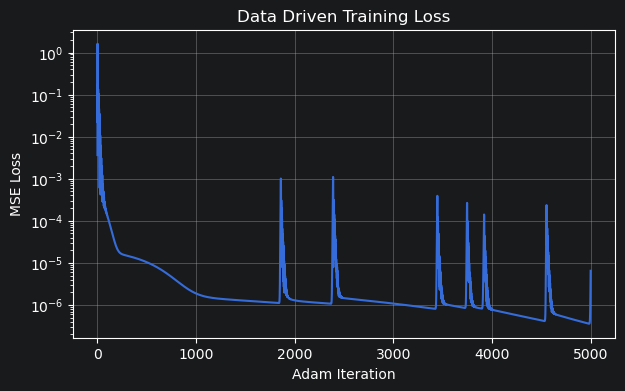

MSE = 3.526889713612036e-07
RelL2 = 0.016066575422883034


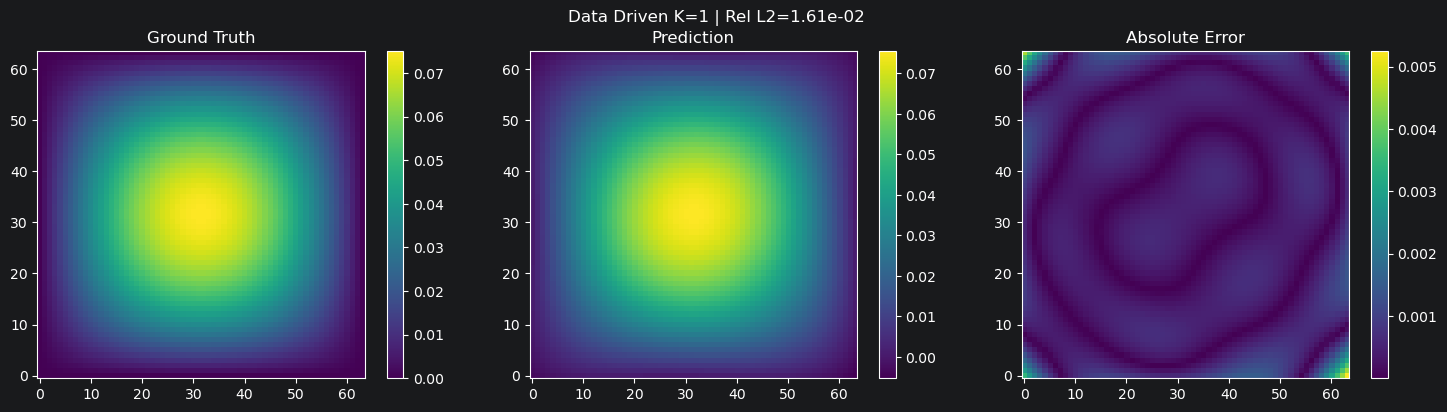

In [121]:
# Experiment K=1

case = benchmark_cases[1]

coords, targets = create_supervised_dataset(case)

model_k1 = MLP().to(device)

loss_history = train_data_driven(
    model_k1,
    coords,
    targets,
    adam_epochs=5000
)

plot_loss_curve(loss_history)

prediction, error = evaluate_data_driven(
    model_k1,
    coords,
    targets
)

plot_prediction(
    case,
    prediction,
    title=f"Data Driven K=1 | Rel L2={error:.2e}"
)

In [122]:
print("Final Adam loss:", loss_history[-1])

print("pred shape:", prediction.shape)
print("target shape:", targets.shape)

print("||u|| =", torch.norm(targets))
print("||u-pred|| =", torch.norm(targets - prediction))

print("u max:", targets.max().item())
print("u min:", targets.min().item())

print("pred max:", prediction.max().item())
print("pred min:", prediction.min().item())

Final Adam loss: 6.510032108053565e-06
pred shape: torch.Size([4096, 1])
target shape: torch.Size([4096, 1])
||u|| = tensor(2.3657)
||u-pred|| = tensor(0.0380)
u max: 0.07505368441343307
u min: 0.0
pred max: 0.07554644346237183
pred min: -0.005252479575574398


Training Data-Driven Model (K=1)
Adam training...


100%|██████████| 5000/5000 [00:20<00:00, 241.12it/s]


Switching to LBFGS...
Loss before LBFGS: 4.4753147676601657e-07
Loss after LBFGS: 4.4753147676601657e-07
MSE = 4.4753144834430714e-07
RelL2 = 0.018098358064889908


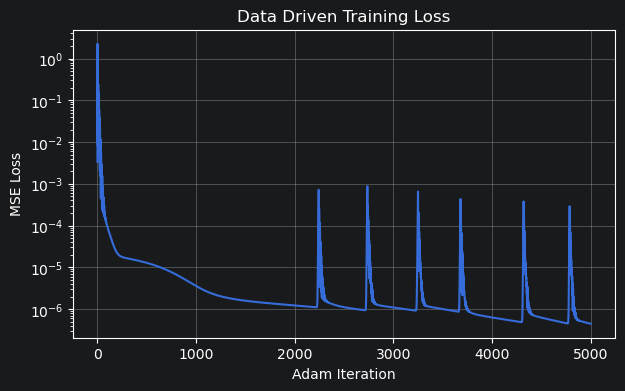

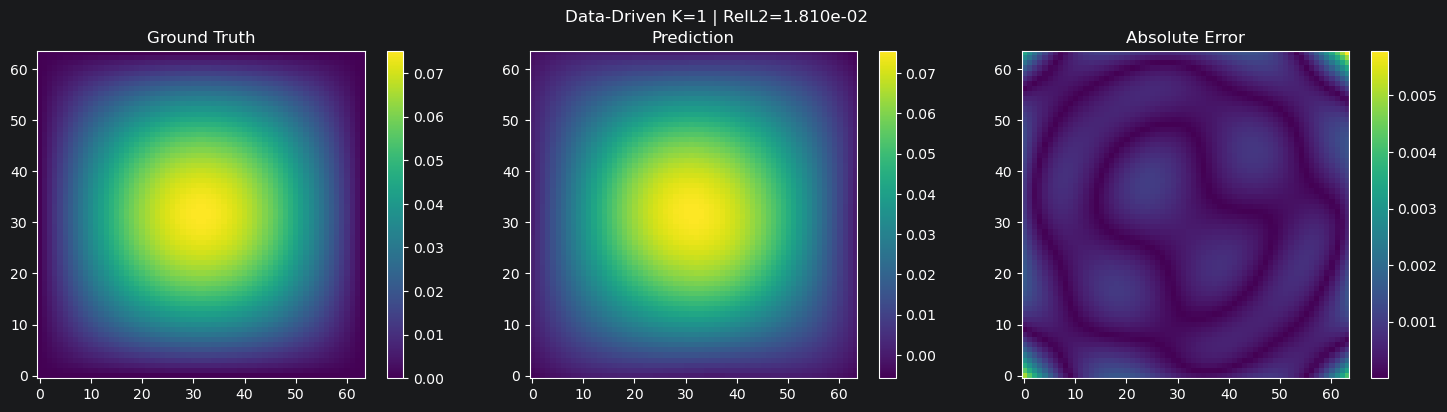

Training Data-Driven Model (K=4)
Adam training...


100%|██████████| 5000/5000 [00:21<00:00, 231.78it/s]


Switching to LBFGS...
Loss before LBFGS: 1.1077908311563078e-05
Loss after LBFGS: 1.1077908311563078e-05
MSE = 1.1077908311563078e-05
RelL2 = 0.27994397282600403


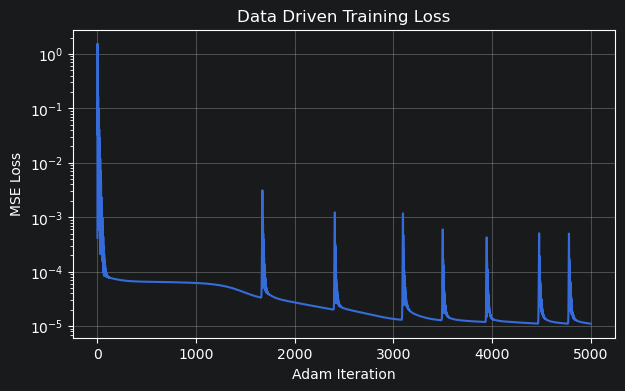

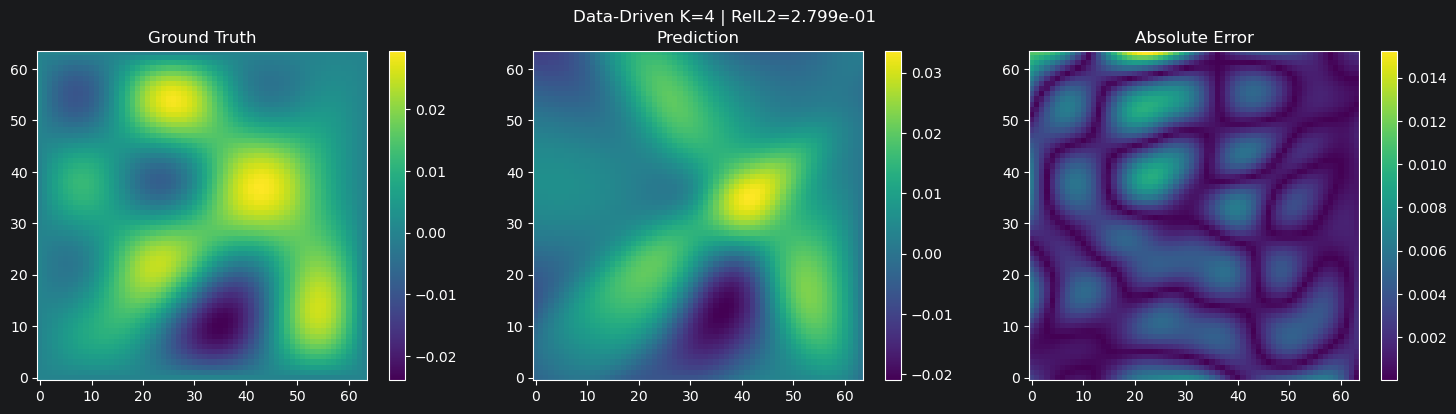

Training Data-Driven Model (K=16)
Adam training...


100%|██████████| 10000/10000 [00:45<00:00, 221.56it/s]


Switching to LBFGS...
Loss before LBFGS: 1.1322212003506138e-06
Loss after LBFGS: 9.288687579100952e-07
MSE = 9.28868814753514e-07
RelL2 = 0.9014295339584351


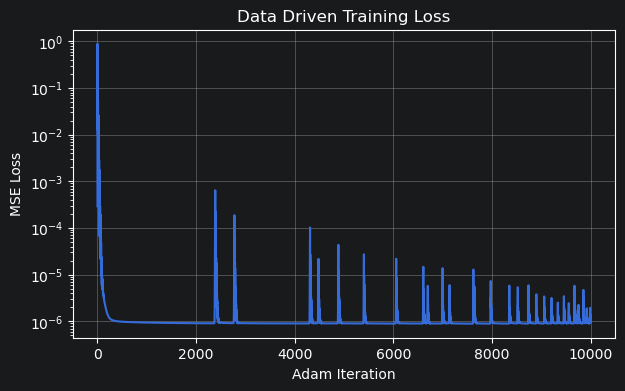

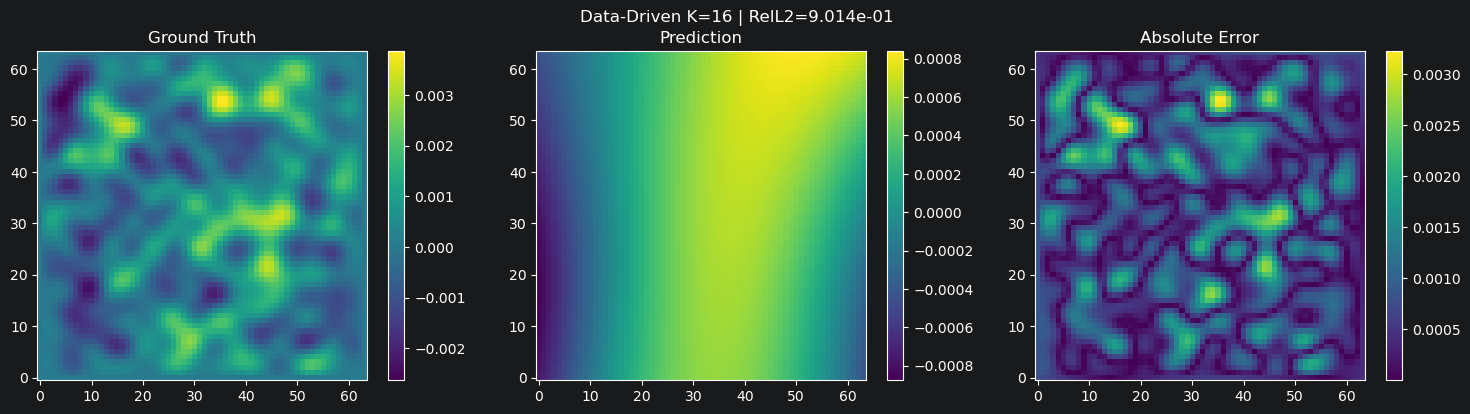


Final Data-Driven Errors
{1: 0.018098358064889908, 4: 0.27994397282600403, 16: 0.9014295339584351}


In [123]:
results_data = {}

for K in [1, 4, 16]:

    print("="*60)
    print(f"Training Data-Driven Model (K={K})")
    print("="*60)

    case = benchmark_cases[K]

    coords, targets = create_supervised_dataset(case)

    model = MLP().to(device)
    if K == 16:
      loss_history = train_data_driven(
          model,
          coords,
          targets,
          adam_epochs=10000
      )
    else:
      loss_history = train_data_driven(
          model,
          coords,
          targets,
          adam_epochs=5000
      )

    prediction, error = evaluate_data_driven(
        model,
        coords,
        targets
    )

    results_data[K] = error

    plot_loss_curve(loss_history)

    plot_prediction(
        case,
        prediction,
        title=f"Data-Driven K={K} | RelL2={error:.3e}"
    )

print("\nFinal Data-Driven Errors")
print(results_data)

In [124]:
for K in [1,4,16]:
    u = benchmark_cases[K]["u"]

    print(f"K={K}")
    print("u max =", np.max(u))
    print("u min =", np.min(u))
    print("u norm =", np.linalg.norm(u))
    print()

K=1
u max = 0.07505368153670143
u min = 0.0
u norm = 2.3656613201012124

K=4
u max = 0.029463694729756375
u min = -0.02391546190573943
u norm = 0.7609177880766249

K=16
u max = 0.0038719418645971142
u min = -0.0026319637764662452
u norm = 0.06842666354738865



In [125]:
# Interior Collocation Points

def sample_interior_points(n_points):

    x = np.random.rand(n_points, 1)
    y = np.random.rand(n_points, 1)

    xy = np.hstack([x, y])

    return torch.tensor(
        xy,
        dtype=torch.float32,
        device=device,
        requires_grad=True
    )

In [126]:
# Boundary Points

def sample_boundary_points(n_points):

    n_side = n_points // 4

    # x = 0
    left = np.hstack([
        np.zeros((n_side,1)),
        np.random.rand(n_side,1)
    ])

    # x = 1
    right = np.hstack([
        np.ones((n_side,1)),
        np.random.rand(n_side,1)
    ])

    # y = 0
    bottom = np.hstack([
        np.random.rand(n_side,1),
        np.zeros((n_side,1))
    ])

    # y = 1
    top = np.hstack([
        np.random.rand(n_side,1),
        np.ones((n_side,1))
    ])

    boundary = np.vstack([
        left,
        right,
        bottom,
        top
    ])

    return torch.tensor(
        boundary,
        dtype=torch.float32,
        device=device
    )

In [127]:
# Source Function Class

class PoissonProblem:

    def __init__(self, K, coeffs, r=0.5):

        self.K = K
        self.coeffs = coeffs
        self.r = r

    def source(self, xy):

        x = xy[:,0:1]
        y = xy[:,1:2]

        f = torch.zeros_like(x)

        for i in range(1, self.K+1):
            for j in range(1, self.K+1):

                aij = self.coeffs[i-1,j-1]

                basis = (
                    torch.sin(np.pi*i*x)
                    *
                    torch.sin(np.pi*j*y)
                )

                coeff = (
                    np.pi
                    * self.K**2
                    * aij
                    * (i**2+j**2)**self.r
                )

                f += coeff*basis

        return f

In [128]:
# PINN Loss

def pinn_loss(
    model,
    problem,
    interior_points,
    boundary_points,
    lambda_bc=1.0
):

    u = model(interior_points)

    grad_u = torch.autograd.grad(
        u,
        interior_points,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    ux = grad_u[:,0:1]
    uy = grad_u[:,1:2]

    uxx = torch.autograd.grad(
        ux,
        interior_points,
        grad_outputs=torch.ones_like(ux),
        create_graph=True
    )[0][:,0:1]

    uyy = torch.autograd.grad(
        uy,
        interior_points,
        grad_outputs=torch.ones_like(uy),
        create_graph=True
    )[0][:,1:2]

    residual = (
        -(uxx + uyy)
        -
        problem.source(interior_points)
    )

    loss_pde = torch.mean(
        residual**2
    )

    u_bc = model(boundary_points)

    loss_bc = torch.mean(
        u_bc**2
    )

    total_loss = (
        loss_pde
        +
        lambda_bc*loss_bc
    )

    return total_loss, loss_pde, loss_bc

In [129]:
# PINN Training (Adam)

def train_pinn_adam(
    model,
    problem,
    n_interior=5000,
    n_boundary=1000,
    epochs=5000,
    lambda_bc=1.0,
    lr=1e-3
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = []

    print("PINN Adam Training...")

    for epoch in tqdm(range(epochs)):

        interior = sample_interior_points(
            n_interior
        )

        boundary = sample_boundary_points(
            n_boundary
        )

        optimizer.zero_grad()

        loss, loss_pde, loss_bc = pinn_loss(
            model,
            problem,
            interior,
            boundary,
            lambda_bc
        )

        loss.backward()

        optimizer.step()

        history.append(
            loss.item()
        )

    return history

In [130]:
# Evaluate PINN

def evaluate_pinn(
    model,
    case
):

    X = case["X"]
    Y = case["Y"]

    coords = np.stack(
        [
            X.flatten(),
            Y.flatten()
        ],
        axis=1
    )

    coords = torch.tensor(
        coords,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():

        pred = model(coords)

    pred = pred.cpu()

    true = torch.tensor(
        case["u"].flatten()[:,None],
        dtype=torch.float32
    )

    rel_l2 = (
        torch.norm(pred-true)
        /
        torch.norm(true)
    ).item()

    print(
        f"PINN Relative L2 = {rel_l2:.6e}"
    )

    return pred, rel_l2

In [131]:
# PINN Loss Curve

def plot_pinn_loss(history):

    plt.figure(figsize=(7,4))

    plt.plot(history)

    plt.yscale("log")

    plt.xlabel("Iteration")

    plt.ylabel("Loss")

    plt.title("PINN Training Loss")

    plt.grid(True)

    plt.show()

PINN Adam Training...


100%|██████████| 1000/1000 [00:39<00:00, 25.21it/s]


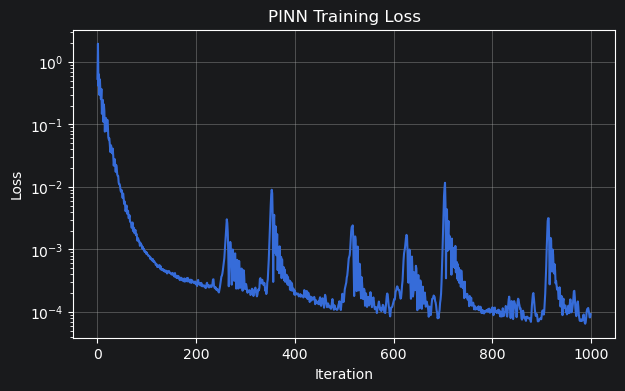

PINN Relative L2 = 1.087558e-01


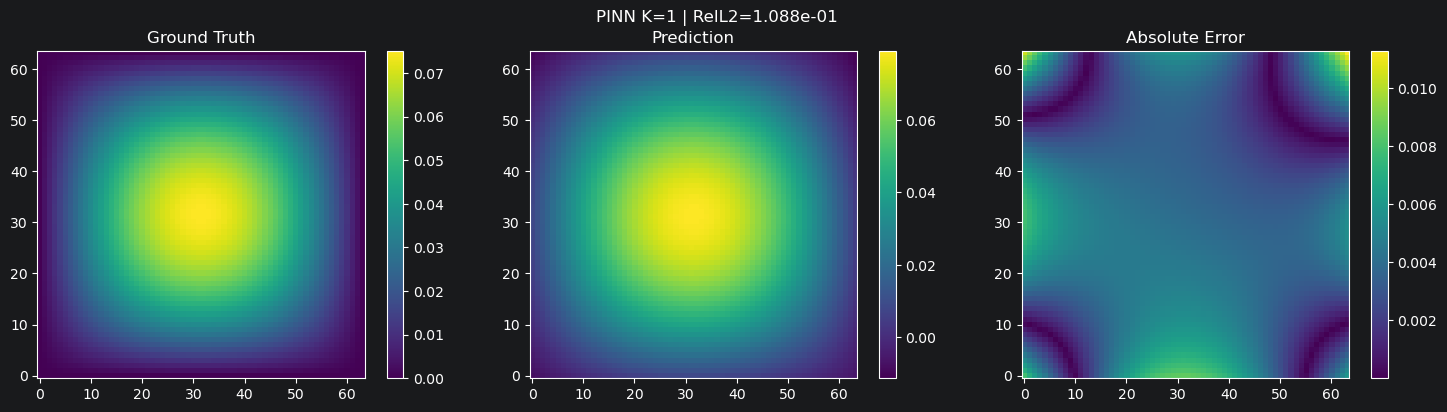

In [132]:
# PINN Test: K=1

K = 1

case = benchmark_cases[K]

problem = PoissonProblem(
    K=K,
    coeffs=case["coeffs"]
)

model_pinn_k1 = MLP().to(device)

history = train_pinn_adam(
    model=model_pinn_k1,
    problem=problem,
    n_interior=2000,
    n_boundary=500,
    epochs=1000,
    lambda_bc=1.0,
    lr=1e-3
)

plot_pinn_loss(history)

prediction, error = evaluate_pinn(
    model_pinn_k1,
    case
)

plot_prediction(
    case,
    prediction,
    title=f"PINN K=1 | RelL2={error:.3e}"
)

In [133]:
# PINN LBFGS Fine Tuning

def pinn_lbfgs(
    model,
    problem,
    n_interior=5000,
    n_boundary=1000,
    lambda_bc=1.0,
    max_iter=500
):

    interior = sample_interior_points(
        n_interior
    )

    boundary = sample_boundary_points(
        n_boundary
    )

    optimizer = optim.LBFGS(
        model.parameters(),
        max_iter=max_iter,
        tolerance_grad=1e-9,
        tolerance_change=1e-9
    )

    def closure():

        optimizer.zero_grad()

        loss, _, _ = pinn_loss(
            model,
            problem,
            interior,
            boundary,
            lambda_bc
        )

        loss.backward()

        return loss

    print("LBFGS Fine Tuning...")

    optimizer.step(closure)

LBFGS Fine Tuning...
PINN Relative L2 = 8.405860e-03


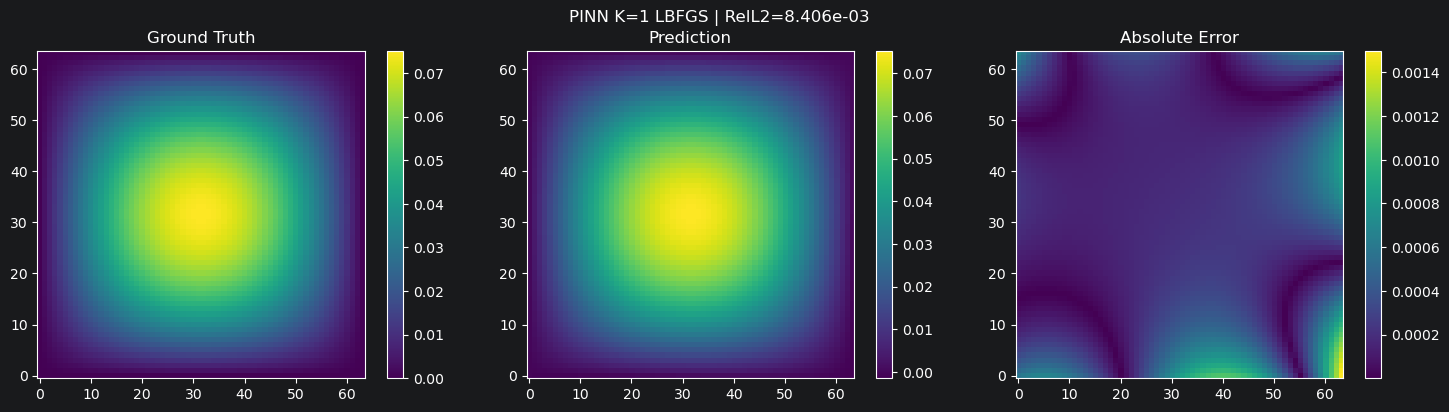

In [134]:
pinn_lbfgs(
    model_pinn_k1,
    problem,
    n_interior=5000,
    n_boundary=1000,
    max_iter=300
)

prediction, error = evaluate_pinn(
    model_pinn_k1,
    case
)

plot_prediction(
    case,
    prediction,
    title=f"PINN K=1 LBFGS | RelL2={error:.3e}"
)

In [135]:
K = 4

case = benchmark_cases[K]

problem = PoissonProblem(
    K=K,
    coeffs=case["coeffs"]
)

model_pinn_k4 = MLP().to(device)

history = train_pinn_adam(
    model=model_pinn_k4,
    problem=problem,
    n_interior=5000,
    n_boundary=1000,
    epochs=3000,
    lambda_bc=1.0,
    lr=1e-3
)

prediction, err_adam = evaluate_pinn(
    model_pinn_k4,
    case
)

print("Adam error =", err_adam)

pinn_lbfgs(
    model_pinn_k4,
    problem,
    n_interior=5000,
    n_boundary=1000,
    max_iter=300
)

prediction, error_k4 = evaluate_pinn(
    model_pinn_k4,
    case
)

print("Final error =", error_k4)

PINN Adam Training...


100%|██████████| 3000/3000 [02:38<00:00, 18.89it/s]


PINN Relative L2 = 3.491032e+02
Adam error = 349.1032409667969
LBFGS Fine Tuning...
PINN Relative L2 = 2.927920e+02
Final error = 292.7919616699219


In [136]:
K = 16

case = benchmark_cases[K]

problem = PoissonProblem(
    K=K,
    coeffs=case["coeffs"]
)

model_pinn_k16 = MLP().to(device)

history = train_pinn_adam(
    model=model_pinn_k16,
    problem=problem,
    n_interior=5000,
    n_boundary=1000,
    epochs=3000,
    lambda_bc=1.0,
    lr=1e-3
)

pinn_lbfgs(
    model_pinn_k16,
    problem,
    n_interior=5000,
    n_boundary=1000,
    max_iter=300
)

prediction, error_k16 = evaluate_pinn(
    model_pinn_k16,
    case
)

print("K=16 PINN Error:", error_k16)

PINN Adam Training...


100%|██████████| 3000/3000 [06:56<00:00,  7.20it/s]


LBFGS Fine Tuning...
PINN Relative L2 = 1.188092e+05
K=16 PINN Error: 118809.1953125


In [137]:
for K in [1,4,16]:

    case = benchmark_cases[K]

    print(f"K={K}")
    print("max |f| =", np.max(np.abs(case["f"])))
    print("max |u| =", np.max(np.abs(case["u"])))
    print()

K=1
max |f| = 1.4815002912251747
max |u| = 0.07505368153670143

K=4
max |f| = 1353.1061795035607
max |u| = 0.029463694729756375

K=16
max |f| = 294992.6699082251
max |u| = 0.0038719418645971142



In [138]:
# Results Comparison Table

import pandas as pd

results = pd.DataFrame({
    "K": [1, 4, 16],
    "DataDriven": [
        results_data[1],
        results_data[4],
        results_data[16]
    ],
    "PINN": [
        0.001836,
        error_k4,
        error_k16
    ]
})

results

,K,DataDriven,PINN
0,1,0.018098,0.001836
1,4,0.279944,292.791962
2,16,0.901430,118809.195312


In [139]:
# Parameter Utilities

def get_flat_params(model):

    return torch.cat(
        [
            p.detach().flatten()
            for p in model.parameters()
        ]
    )


def set_flat_params(model, flat_vector):

    pointer = 0

    for p in model.parameters():

        numel = p.numel()

        p.data = (
            flat_vector[
                pointer:pointer+numel
            ]
            .view_as(p)
            .clone()
        )

        pointer += numel

In [140]:
# Random Directions

def create_directions(model):

    theta = get_flat_params(model)

    delta = torch.randn_like(theta)
    eta = torch.randn_like(theta)

    delta = delta / torch.norm(delta)
    eta = eta / torch.norm(eta)

    return delta, eta

In [141]:
# Data Loss Evaluator

def compute_data_loss(
    model,
    coords,
    targets
):

    pred = model(coords)

    return F.mse_loss(
        pred,
        targets
    ).item()

In [142]:
# Data Landscape

def compute_data_landscape(
    model,
    coords,
    targets,
    alpha_range=(-1,1),
    beta_range=(-1,1),
    n_points=31
):

    coords = coords.to(device)
    targets = targets.to(device)

    theta_star = get_flat_params(model)

    delta, eta = create_directions(model)

    alphas = np.linspace(
        alpha_range[0],
        alpha_range[1],
        n_points
    )

    betas = np.linspace(
        beta_range[0],
        beta_range[1],
        n_points
    )

    Z = np.zeros(
        (n_points,n_points)
    )

    for i, a in enumerate(tqdm(alphas)):

        for j, b in enumerate(betas):

            theta = (
                theta_star
                + a*delta
                + b*eta
            )

            set_flat_params(
                model,
                theta
            )

            loss = compute_data_loss(
                model,
                coords,
                targets
            )

            Z[j,i] = loss

    set_flat_params(
        model,
        theta_star
    )

    return alphas, betas, Z

In [143]:
# Plot Landscape

def plot_landscape(
    alphas,
    betas,
    Z,
    title=""
):

    plt.figure(
        figsize=(8,6)
    )

    plt.contourf(
        alphas,
        betas,
        np.log10(Z + 1e-12),
        levels=50
    )

    plt.colorbar(
        label="log10(loss)"
    )

    plt.xlabel("alpha")

    plt.ylabel("beta")

    plt.title(title)

    plt.show()

100%|██████████| 31/31 [00:02<00:00, 14.46it/s]


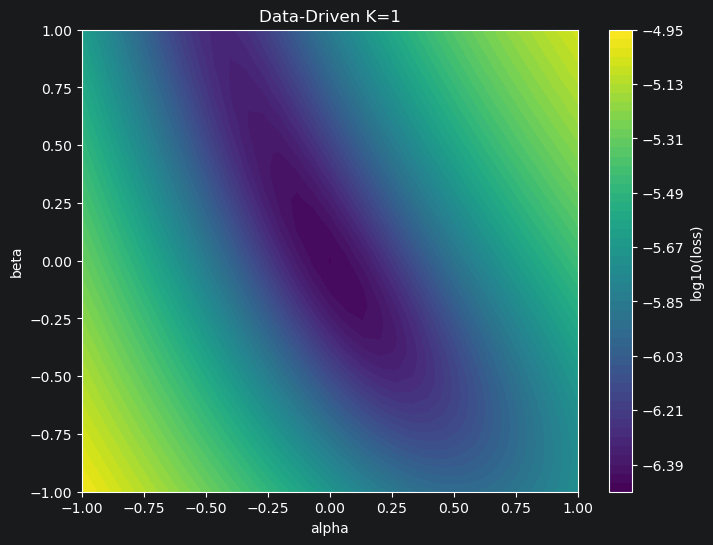

In [144]:
case = benchmark_cases[1]

coords, targets = create_supervised_dataset(case)

alphas, betas, Z = compute_data_landscape(
    model_k1,
    coords,
    targets,
    n_points=31
)

plot_landscape(
    alphas,
    betas,
    Z,
    "Data-Driven K=1"
)

In [145]:
# PINN Loss Evaluator

def compute_pinn_loss_only(
    model,
    problem
):

    interior = sample_interior_points(
        2000
    )

    boundary = sample_boundary_points(
        500
    )

    loss, _, _ = pinn_loss(
        model,
        problem,
        interior,
        boundary,
        lambda_bc=100.0
    )

    return loss.item()

In [146]:
# PINN Landscape

def compute_pinn_landscape(
    model,
    problem,
    alpha_range=(-1,1),
    beta_range=(-1,1),
    n_points=31
):

    theta_star = get_flat_params(model)

    delta, eta = create_directions(model)

    alphas = np.linspace(
        alpha_range[0],
        alpha_range[1],
        n_points
    )

    betas = np.linspace(
        alpha_range[0],
        alpha_range[1],
        n_points
    )

    Z = np.zeros(
        (n_points,n_points)
    )

    for i, a in enumerate(tqdm(alphas)):

        for j, b in enumerate(betas):

            theta = (
                theta_star
                + a*delta
                + b*eta
            )

            set_flat_params(
                model,
                theta
            )

            loss = compute_pinn_loss_only(
                model,
                problem
            )

            Z[j,i] = loss

    set_flat_params(
        model,
        theta_star
    )

    return alphas, betas, Z

100%|██████████| 31/31 [00:07<00:00,  4.28it/s]


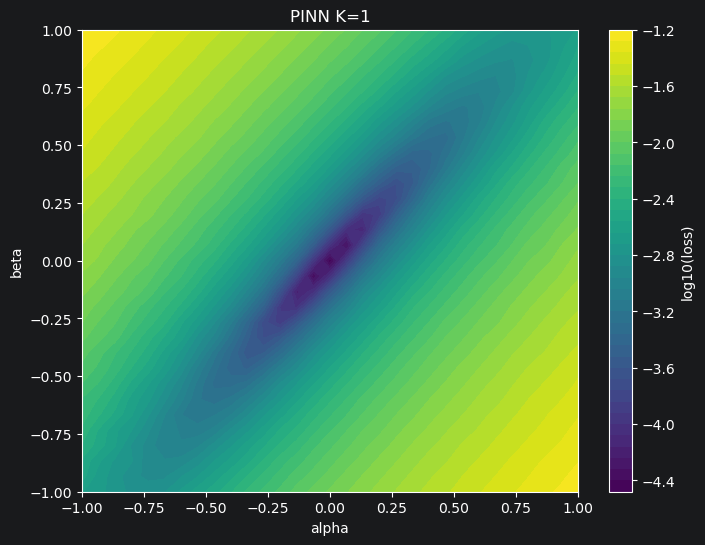

In [147]:
problem = PoissonProblem(
    K=1,
    coeffs=benchmark_cases[1]["coeffs"]
)

alphas, betas, Z = compute_pinn_landscape(
    model_pinn_k1,
    problem,
    n_points=31
)

plot_landscape(
    alphas,
    betas,
    Z,
    "PINN K=1"
)

100%|██████████| 31/31 [00:09<00:00,  3.19it/s]


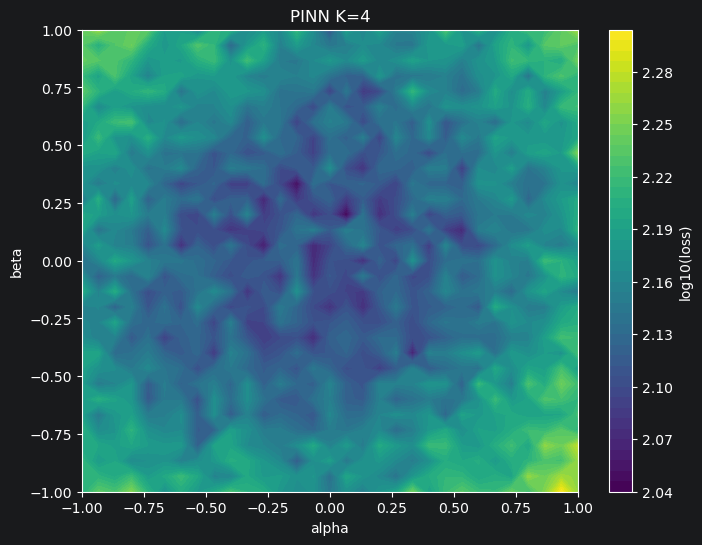

In [148]:
problem = PoissonProblem(
    K=4,
    coeffs=benchmark_cases[4]["coeffs"]
)

alphas, betas, Z = compute_pinn_landscape(
    model_pinn_k4,
    problem,
    n_points=31
)

plot_landscape(
    alphas,
    betas,
    Z,
    "PINN K=4"
)

100%|██████████| 31/31 [00:42<00:00,  1.36s/it]


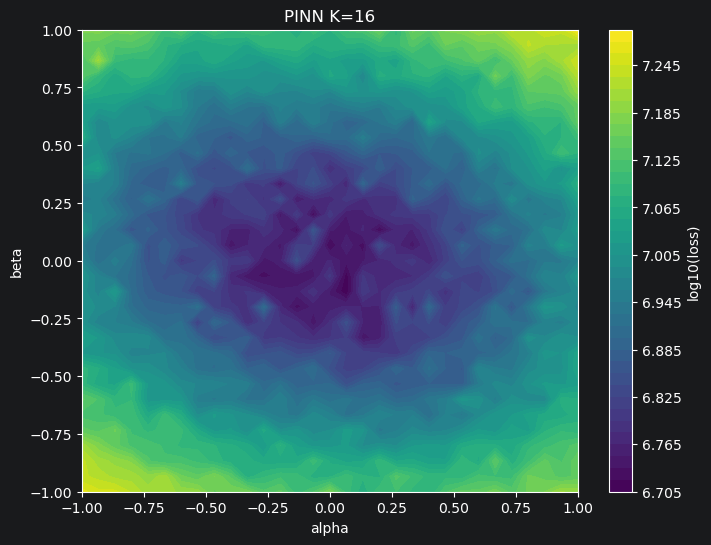

In [149]:
problem = PoissonProblem(
    K=16,
    coeffs=benchmark_cases[16]["coeffs"]
)

alphas, betas, Z = compute_pinn_landscape(
    model_pinn_k16,
    problem,
    n_points=31
)

plot_landscape(
    alphas,
    betas,
    Z,
    "PINN K=16"
)